In [4]:
import os
import time
import kagglehub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gc
import json
from datetime import datetime

import tensorflow.keras.preprocessing.image
import tensorflow.keras
import tensorflow.keras.applications

I0000 00:00:1775900297.547103   25732 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775900297.579022   25732 pjrt_api.cc:96] PJRT_Api is set for device type gpu
I0000 00:00:1775900297.581804   25732 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775900298.469352   25732 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

dataset_root_folder = os.path.join(path, "plantvillage dataset", "color")

Path to dataset files: /home/yavilag/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3


In [6]:
# --- Configuración ---
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32
KERNEL_SIZE = (5, 5)
EPOCHS = 10

In [7]:
# --- Función de Pre-procesamiento personalizado
def my_preprocessing_func(img):
    # El generador entrega la imagen como float32 después del rescale
    # Aplicamos el filtro Gaussiano
    img_blurred = cv2.GaussianBlur(img, KERNEL_SIZE, 0)
    return img_blurred

In [8]:
# --- Configuración del Generador
# No se usan for ni listas

datagen = tensorflow.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,           # Normalización (Sustituye tu /255.0)
    preprocessing_function=my_preprocessing_func,
    validation_split=0.2      # Sustituye a train_test_split
)

print("Vinculando generadores con el disco duro...")

Vinculando generadores con el disco duro...


In [10]:
# --- Generador de Entrenamiento
train_generator = datagen.flow_from_directory(
    dataset_root_folder,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# --- Generador de Validación
val_generator = datagen.flow_from_directory(
    dataset_root_folder,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


Forma del lote de imágenes: (32, 224, 224, 3)
Total de clases detectadas: 38


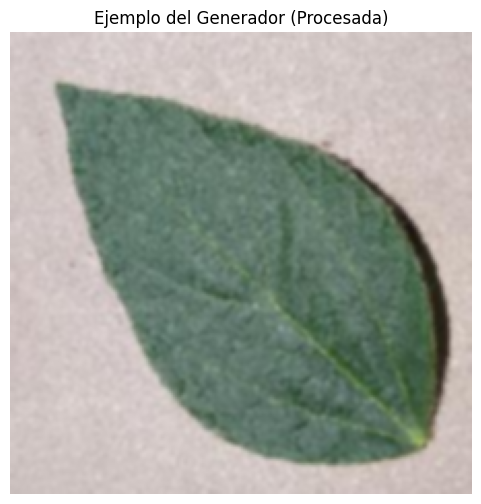

In [11]:
# --- Verificación Visual (Para estar seguros de que funciona) ---
# Obtener lote (batch) de 32 imágenes
x_batch, y_batch = next(train_generator)

print(f"Forma del lote de imágenes: {x_batch.shape}") # Debería ser (32, 224, 224, 3)
print(f"Total de clases detectadas: {train_generator.num_classes}")

# Primera imagen del tote
plt.figure(figsize=(6, 6))
plt.imshow(x_batch[0])
plt.title("Ejemplo del Generador (Procesada)")
plt.axis('off')
plt.show()

In [12]:
# --- Limpieza
gc.collect()

3767

In [13]:
# --- Cargar el modelo base (MobileNetV2) sin la última capa (top)
# Se usan los pesos de 'imagenet' para no empezar de cero
base_model = tensorflow.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

E0000 00:00:1775900445.449065   25732 cuda_platform.cc:59] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
# ---  Congelar el modelo base para que no se alteren sus conocimientos previos
base_model.trainable = False

In [15]:
# --- Construir la arquitectura ---
model = tensorflow.keras.models.Sequential([
    base_model,
    tensorflow.keras.layers.GlobalAveragePooling2D(),
    tensorflow.keras.layers.Dropout(0.3),
    tensorflow.keras.layers.Dense(256, activation='relu'),
    tensorflow.keras.layers.BatchNormalization(),
    tensorflow.keras.layers.Dropout(0.3),
    tensorflow.keras.layers.Dense(128, activation='relu'),
    tensorflow.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

# Se agregan optimizaciones directamente para evaluar más adelante

In [16]:
# --- Compilar el modelo ---
model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tensorflow.keras.metrics.Precision(name='precision'),
        tensorflow.keras.metrics.Recall(name='recall'),
        tensorflow.keras.metrics.AUC(name='auc'),
        tensorflow.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy')
    ]
)

model.summary() # Muestra la estructura de la red

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,742 (10.01 MB)

 Trainable params: 366,246 (1.40 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [17]:
# --- Callbacks ---
callbacks = [
    tensorflow.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tensorflow.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tensorflow.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [18]:
# --- Entrenar el modelo ---
print("Iniciando entrenamiento...")
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

Iniciando entrenamiento...
Epoch 1/10


I0000 00:00:1775900471.882410   25732 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.7203 - auc: 0.9654 - loss: 1.0373 - precision: 0.8891 - recall: 0.6152 - top3_accuracy: 0.8534
Epoch 1: val_accuracy improved from None to 0.92064, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 718s 526ms/step - accuracy: 0.8176 - auc: 0.9909 - loss: 0.6153 - precision: 0.9016 - recall: 0.7543 - top3_accuracy: 0.9359 - val_accuracy: 0.9206 - val_auc: 0.9980 - val_loss: 0.2334 - val_precision: 0.9432 - val_recall: 0.9023 - val_top3_accuracy: 0.9887 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8821 - auc: 0.9961 - loss: 0.3548 - precision: 0.9157 - recall: 0.8564 - top3_accuracy: 0.9781
Epoch 2: val_accuracy improved from 0.92064 to 0.92479, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 719s 529ms/step - accuracy: 0.8870 - auc: 0.9964 - loss: 0

In [19]:
# --- MÉTRICAS ADICIONALES ---
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Obtener predicciones
print("\n" + "="*60)
print("ANÁLISIS DETALLADO DE MÉTRICAS")
print("="*60)

val_generator.reset()
y_pred_prob = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Reporte de clasificación
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_labels))



ANÁLISIS DETALLADO DE MÉTRICAS
340/340 ━━━━━━━━━━━━━━━━━━━━ 120s 351ms/step

--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.96      0.96       126
                                 Apple___Black_rot       0.97      0.98      0.97       124
                          Apple___Cedar_apple_rust       0.87      1.00      0.93        55
                                   Apple___healthy       0.98      0.97      0.98       329
                               Blueberry___healthy       0.99      0.99      0.99       300
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       210
                 Cherry_(including_sour)___healthy       0.98      0.96      0.97       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.84      0.76      0.80       102
                       Corn_(maize)___Common_rust_       1.00  

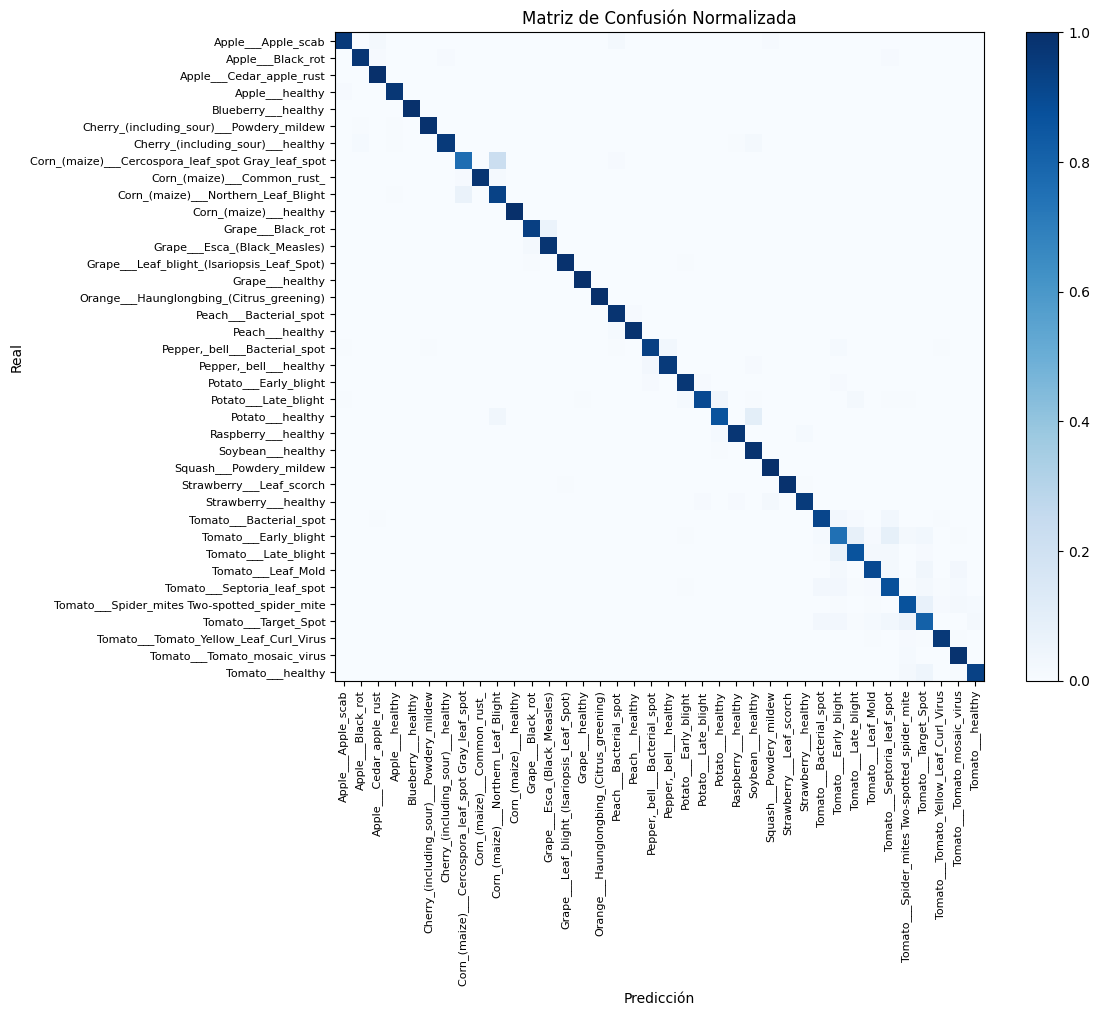

In [20]:
# Matriz de confusión normalizada
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
plt.title('Matriz de Confusión Normalizada')
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=90, fontsize=8)
plt.yticks(tick_marks, class_labels, fontsize=8)
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [21]:
# --- Gráficos de métricas ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
precision = history.history['precision']
val_precision = history.history['val_precision']
recall = history.history['recall']
val_recall = history.history['val_recall']
auc = history.history['auc']
val_auc = history.history['val_auc']

epochs_range = range(len(acc))

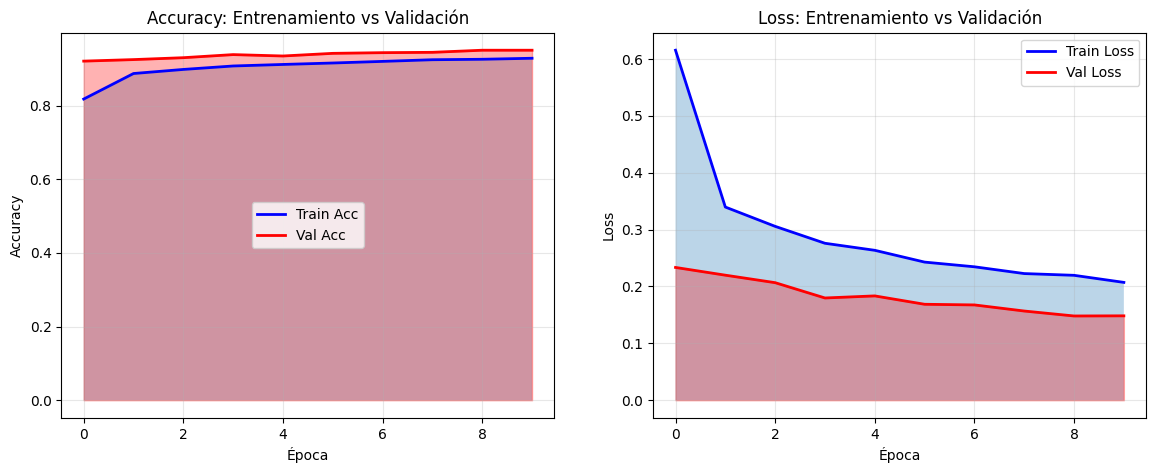

In [22]:
# Gráfico 1: Accuracy y Loss
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-', label='Train Acc', linewidth=2)
plt.plot(epochs_range, val_acc, 'r-', label='Val Acc', linewidth=2)
plt.fill_between(epochs_range, acc, alpha=0.3)
plt.fill_between(epochs_range, val_acc, alpha=0.3, color='red')
plt.legend()
plt.title('Accuracy: Entrenamiento vs Validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-', label='Train Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-', label='Val Loss', linewidth=2)
plt.fill_between(epochs_range, loss, alpha=0.3)
plt.fill_between(epochs_range, val_loss, alpha=0.3, color='red')
plt.legend()
plt.title('Loss: Entrenamiento vs Validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.savefig('accuracy_loss_curves.png', dpi=150)
plt.show()

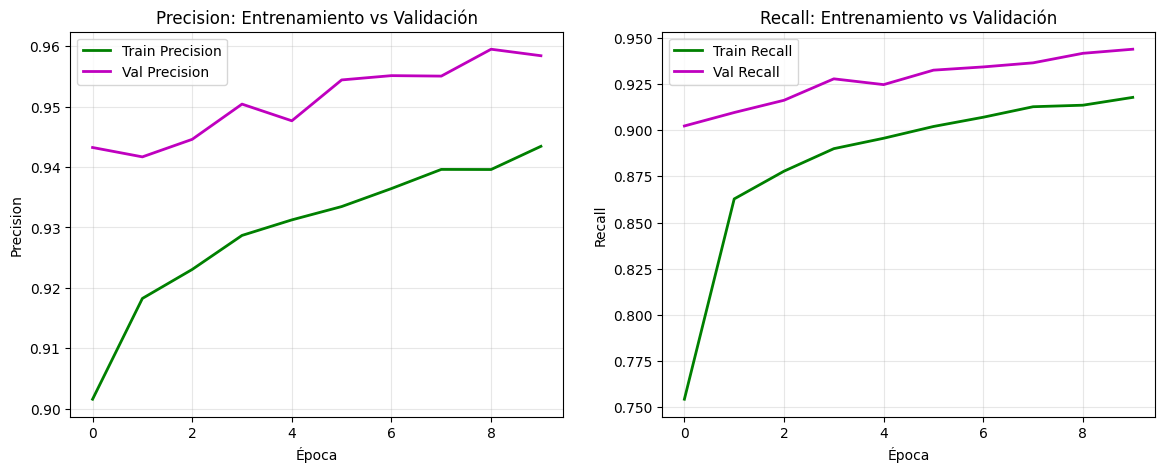

In [23]:
# Gráfico 2: Precision y Recall
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, precision, 'g-', label='Train Precision', linewidth=2)
plt.plot(epochs_range, val_precision, 'm-', label='Val Precision', linewidth=2)
plt.legend()
plt.title('Precision: Entrenamiento vs Validación')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, recall, 'g-', label='Train Recall', linewidth=2)
plt.plot(epochs_range, val_recall, 'm-', label='Val Recall', linewidth=2)
plt.legend()
plt.title('Recall: Entrenamiento vs Validación')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.grid(True, alpha=0.3)
plt.savefig('precision_recall_curves.png', dpi=150)
plt.show()

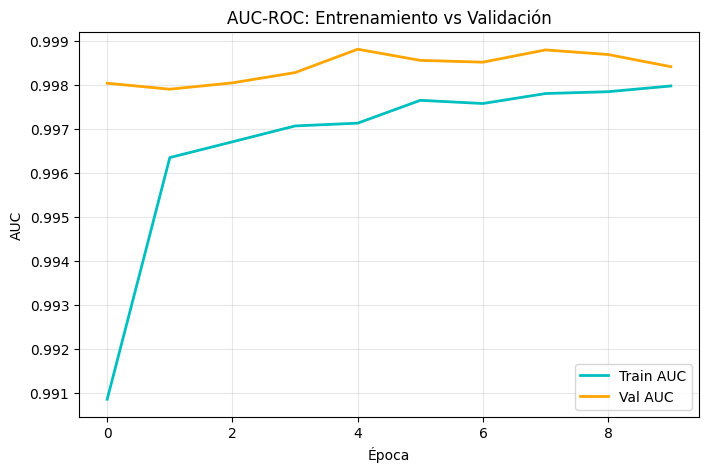

In [24]:
# Gráfico 3: AUC
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, auc, 'c-', label='Train AUC', linewidth=2)
plt.plot(epochs_range, val_auc, 'orange', label='Val AUC', linewidth=2)
plt.legend()
plt.title('AUC-ROC: Entrenamiento vs Validación')
plt.xlabel('Época')
plt.ylabel('AUC')
plt.grid(True, alpha=0.3)
plt.savefig('auc_curves.png', dpi=150)
plt.show()

In [25]:
# --- EXPORTAR MODELO Y CLASES ---
output_dir = 'modelo_exportado'
os.makedirs(output_dir, exist_ok=True)

# Guardar modelo en formato Keras
model_path = os.path.join(output_dir, 'modelo_plantas.keras')
model.save(model_path)
print(f"\nModelo guardado en: {model_path}")

# Guardar clases en JSON
classes_path = os.path.join(output_dir, 'clases.json')
with open(classes_path, 'w', encoding='utf-8') as f:
    json.dump(class_labels, f, indent=2, ensure_ascii=False)
print(f"Clases guardadas en: {classes_path}")


Modelo guardado en: modelo_exportado/modelo_plantas.keras
Clases guardadas en: modelo_exportado/clases.json


In [26]:
# Guardar métricas del entrenamiento
metrics_path = os.path.join(output_dir, 'metricas_entrenamiento.json')
metrics_summary = {
    'fecha_entrenamiento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'epochs_ejecutados': len(acc),
    'tiempo_entrenamiento_segundos': round(training_time, 2),
    'metricas_finales': {
        'train_accuracy': float(acc[-1]),
        'val_accuracy': float(val_acc[-1]),
        'train_loss': float(loss[-1]),
        'val_loss': float(val_loss[-1]),
        'train_precision': float(precision[-1]),
        'val_precision': float(val_precision[-1]),
        'train_recall': float(recall[-1]),
        'val_recall': float(val_recall[-1]),
        'train_auc': float(auc[-1]),
        'val_auc': float(val_auc[-1])
    },
    'mejor_val_accuracy': float(max(val_acc)),
    'num_clases': train_generator.num_classes,
    'nombres_clases': class_labels
}
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)
print(f"Métricas guardadas en: {metrics_path}")

print("\n" + "="*60)
print("OPTIMIZACIÓN COMPLETADA - Archivos exportados exitosamente")
print("="*60)

Métricas guardadas en: modelo_exportado/metricas_entrenamiento.json

OPTIMIZACIÓN COMPLETADA - Archivos exportados exitosamente
